# Linear Regression

<img src='https://miro.medium.com/max/1400/1*2ZnDb5b6UtBZ41Wy90MTkw.jpeg'>

#  1. Simple linear regression
<img src="https://miro.medium.com/max/584/1*BDnev89iHmFqbB-HY1MuRQ.png">

# Metal rod expansion with different temperatures:

We all know that when the temperature of a metal increases, it begins to expand. So, we experimented with exposing a metal rod to different temperatures and recorded its length as follows:

x = [20,25,30,35,40,45,50,55,60,65]

y = [0.5,1.8,5,6.2,6,6.5,7.8,9.4,9.8,10.9]

In [13]:
import matplotlib.pyplot as plt
import numpy as np

In [14]:
X = np.array([20,25,30,35,40,45,50,55,60,65])
Y = np.array([0.5,1.8,5,6.2,6,6.5,7.8,9.4,9.8,10.9])
X_test = np.linspace(20,65,num=100)

In [15]:
# Simple linrea regression
def LR(X,Y):
    # Mean X and Y
    mean_X = np.mean(X)
    mean_Y = np.mean(Y)
    # Total number of values
    n = len(X)
    # Using the formula to calculate 'a' and 'b'
    numerator = 0
    denomenator = 0
    for i in range(n):
        numerator += (X[i] - mean_X) * (Y[i] - mean_Y)
        denomenator += (X[i] - mean_X) ** 2
    
    a = numerator / denomenator
    b = mean_Y - (a * mean_X)
#     print("Coefficients")
#     print(a, b)
    return a,b

# Linear regression

0.21442424242424246 -2.7230303030303054


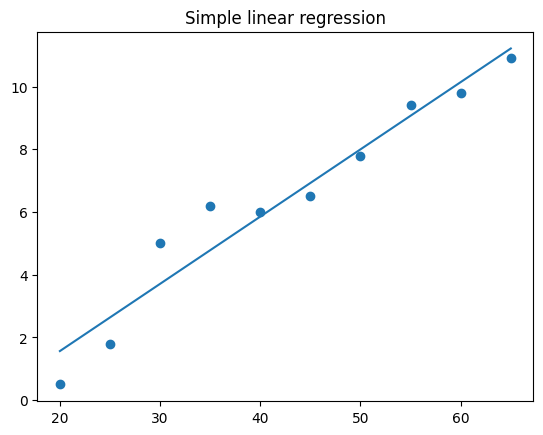

In [16]:
a,b = LR(X,Y)
print(a,b)
Y_pred_test = a*X_test + b
plt.title("Simple linear regression")
plt.scatter(X,Y)
plt.plot(X_test,Y_pred_test);

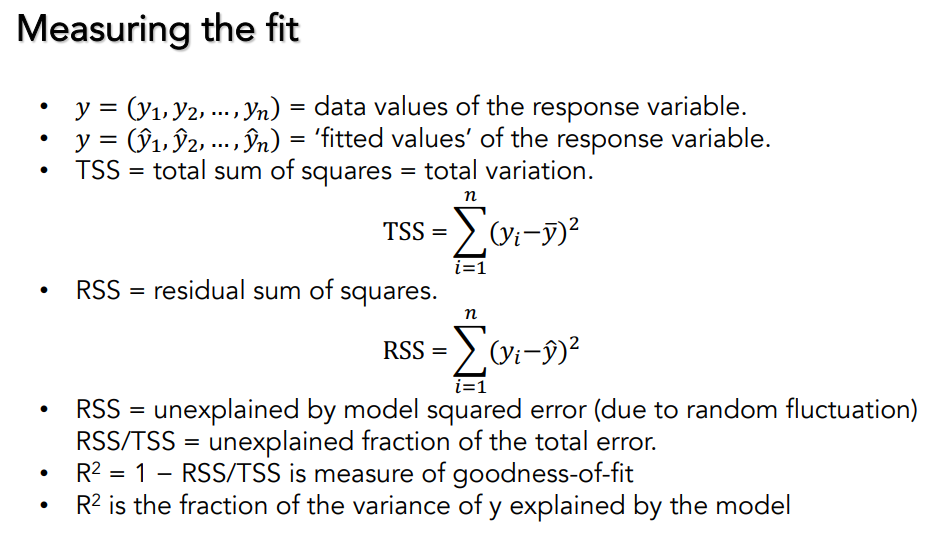

In [17]:
Y_pred_train = a*X + b

In [18]:
TSS = sum([(y - np.mean(Y))**2 for y in Y])
RSS = sum([(y - y_pred_train)**2 for y, y_pred_train in zip(Y, Y_pred_train)])
R2 = 1 - RSS/TSS

In [19]:
print(f'R2 is: {R2}')

R2 is: 0.9397488946686738


# 2. Multiple Linear Regression "Polynomial"

<img src='https://thesiswhispererhome.files.wordpress.com/2019/08/normal-equation-1.jpg'>

In [20]:
# Normal equation
def calculate_w(X,Y):
    ## write your code
    XT = X.T
    XTX = XT.dot(X)
    XTX_inverse = np.linalg.inv(XTX)
    XTX_inverse_XT = XTX_inverse.dot(XT)
    
    W = XTX_inverse_XT.dot(Y)
    

    return W

In [ ]:
def polynomial(X, degree):
    X_poly = []
    ## write your code
    
    X = np.array(X).reshape(-1, 1)
    X_poly = np.ones((X.shape[0], 1))

    
    for d in range(1, degree + 1):
        X_poly = np.c_[X_poly, X**d]

    

    return X_poly

Shape of x_test_pol (100, 4)
Shape of W (4,)


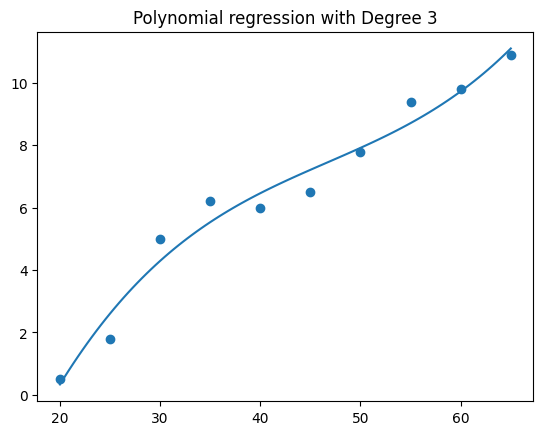

In [22]:
degree = 3
X_poly = polynomial(X, degree)
W = calculate_w(X_poly, Y)
X_test_poly = polynomial(X_test, degree)
print("Shape of x_test_pol", X_test_poly.shape)
print("Shape of W", W.shape)
Y_pred = np.matmul(X_test_poly, W)

plt.plot(X_test, Y_pred)
plt.title(f"Polynomial regression with Degree {degree}")
plt.scatter(X,Y)

In [ ]:
Y_pred_train_poly = np.matmul( X_poly, W)
TSS_poly = np.sum((Y - np.mean(Y))**2)
RSS_poly = np.sum((Y - Y_pred_train_poly)**2)
R2_poly = 1 - RSS_poly / TSS_poly
print(f'r2 for polynomial regression (degree {degree}): {R2_poly}')

R2 for polynomial regression (degree 3): 0.9715214342650947
